In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries loaded!")

Libraries loaded!


In [20]:
df = pd.read_csv("../data/market_data.csv", header=[0, 1], index_col=0)

df.head()

Price            Close                                               \
Ticker             GLD        QQQ        SPY        TLT         USO   
Date                                                                  
2010-01-04  109.800003  40.204666  84.368965  54.849907  322.160004   
2010-01-05  109.699997  40.204666  84.592300  55.204159  323.279999   
2010-01-06  111.510002  39.962162  84.651840  54.465111  327.760010   
2010-01-07  110.820000  39.988152  85.009232  54.556759  325.760010   
2010-01-08  111.370003  40.317268  85.292091  54.532330  327.440002   

Price                        High                                   \
Ticker           ^VIX         GLD        QQQ        SPY        TLT   
Date                                                                 
2010-01-04  20.040001  110.139999  40.265297  84.413631  55.027020   
2010-01-05  19.350000  110.389999  40.273956  84.629525  55.350733   
2010-01-06  19.160000  111.769997  40.317266  84.860286  55.124703   
2010-01-07  19.059999  111.290001  40.074764  85.113455  54.746085   
2010-01-08  18.129999  111.580002  40.317268  85.329316  54.697225   

Price                                     Low                        \
Ticker             USO       ^VIX         GLD        QQQ        SPY   
Date                                                                  
2010-01-04  322.399994  21.680000  109.309998  40.074752  83.014059   
2010-01-05  323.600006  20.129999  109.260002  39.979480  84.011627   
2010-01-06  329.519989  19.680000  110.410004  39.901535  84.443394   
2010-01-07  328.640015  19.709999  110.620003  39.771625  84.257331   
2010-01-08  329.359985  19.270000  110.260002  39.780283  84.614641   

Price                                               Open             \
Ticker            TLT         USO       ^VIX         GLD        QQQ   
Date                                                                  
2010-01-04  54.709441  318.959991  20.030001  109.820000  40.126720   
2010-01-05  54.965973  319.440002  19.340000  109.879997  40.178684   
2010-01-06  54.428468  319.119995  18.770000  110.709999  40.187352   
2010-01-07  54.428506  325.440002  18.700001  111.070000  40.022797   
2010-01-08  54.208642  323.600006  18.110001  111.519997  39.901538   

Price                                                      Volume            \
Ticker            SPY        TLT         USO       ^VIX       GLD       QQQ   
Date                                                                          
2010-01-04  83.654290  54.868228  320.320007  21.680000  16224100  62822800   
2010-01-05  84.316856  54.996512  322.000000  20.049999  14213100  62935600   
2010-01-06  84.510392  55.069734  322.559998  19.590000  24981900  96033000   
2010-01-07  84.495556  54.489578  326.959991  19.680000  13609800  77094100   
2010-01-08  84.785862  54.666692  325.040009  19.270000  15894600  88886600   

Price                                         
Ticker            SPY      TLT      USO ^VIX  
Date                                          
2010-01-04  118944600  2829100  1426038    0  
2010-01-05  111579900  2841600  1306275    0  
2010-01-06  116074400  4099600  2473725    0  
2010-01-07  131091100  2793200  1252963    0  
2010-01-08  126402800  2910700  1174188    0

In [21]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isna().sum().sum())

Shape: (4024, 30)

Columns:
MultiIndex([( 'Close',  'GLD'),
            ( 'Close',  'QQQ'),
            ( 'Close',  'SPY'),
            ( 'Close',  'TLT'),
            ( 'Close',  'USO'),
            ( 'Close', '^VIX'),
            (  'High',  'GLD'),
            (  'High',  'QQQ'),
            (  'High',  'SPY'),
            (  'High',  'TLT'),
            (  'High',  'USO'),
            (  'High', '^VIX'),
            (   'Low',  'GLD'),
            (   'Low',  'QQQ'),
            (   'Low',  'SPY'),
            (   'Low',  'TLT'),
            (   'Low',  'USO'),
            (   'Low', '^VIX'),
            (  'Open',  'GLD'),
            (  'Open',  'QQQ'),
            (  'Open',  'SPY'),
            (  'Open',  'TLT'),
            (  'Open',  'USO'),
            (  'Open', '^VIX'),
            ('Volume',  'GLD'),
            ('Volume',  'QQQ'),
            ('Volume',  'SPY'),
            ('Volume',  'TLT'),
            ('Volume',  'USO'),
            ('Volume', '^VIX')],
           

We have:

4,024 trading days
6 assets: GLD, QQQ, SPY, TLT, USO, VIX
OHLCV data for each
0 missing values

In [22]:
# Use closing prices
close = df["Close"]

# Daily percentage returns
returns = close.pct_change().dropna()

returns.head()

Ticker,GLD,QQQ,SPY,TLT,USO,^VIX
Date,,,,,,
2010-01-05,-0.000911,0.000000,0.002647,0.006459,0.003477,-0.034431
2010-01-06,0.016500,-0.006032,0.000704,-0.013388,0.013858,-0.009819
2010-01-07,-0.006188,0.000650,0.004222,0.001683,-0.006102,-0.005219
2010-01-08,0.004963,0.008230,0.003327,-0.000448,0.005157,-0.048793
2010-01-11,0.013289,-0.004082,0.001397,-0.005487,-0.009528,-0.031991


In [23]:
returns.describe()

Ticker,GLD,QQQ,SPY,TLT,USO,^VIX
count,4023.000000,4023.000000,4023.000000,4023.000000,4023.000000,4023.000000
mean,0.000369,0.000762,0.000577,0.000152,-0.000132,0.003083
std,0.009964,0.013004,0.010841,0.009510,0.022197,0.082941
min,-0.087808,-0.119788,-0.109424,-0.066683,-0.253150,-0.357539
25%,-0.004785,-0.004723,-0.003706,-0.005646,-0.011138,-0.042041
50%,0.000522,0.001197,0.000705,0.000554,0.000687,-0.006659
75%,0.005618,0.007351,0.005790,0.005770,0.011948,0.035541
max,0.049038,0.120031,0.105019,0.075196,0.166667,1.155979


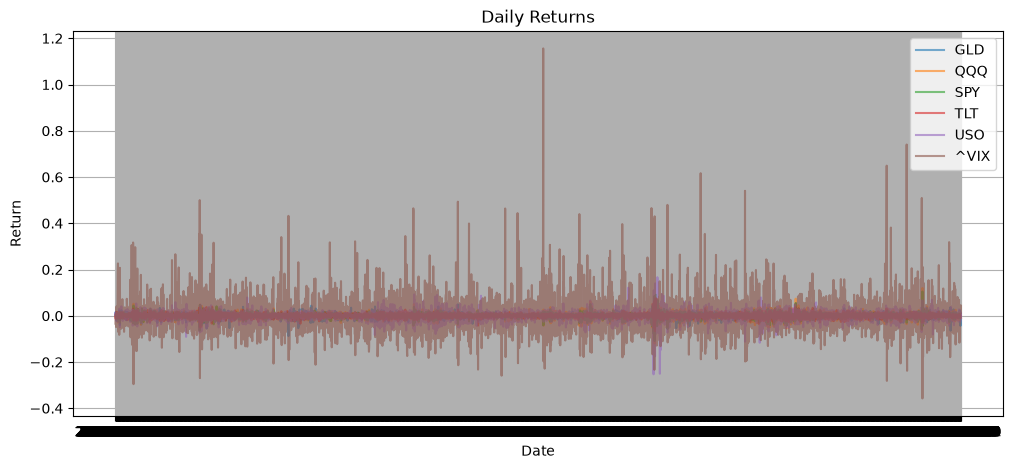

In [24]:
plt.figure(figsize=(12, 5))

for ticker in returns.columns:
    plt.plot(returns.index, returns[ticker], label=ticker, alpha=0.6)

plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.show()

30-day rolling volatility

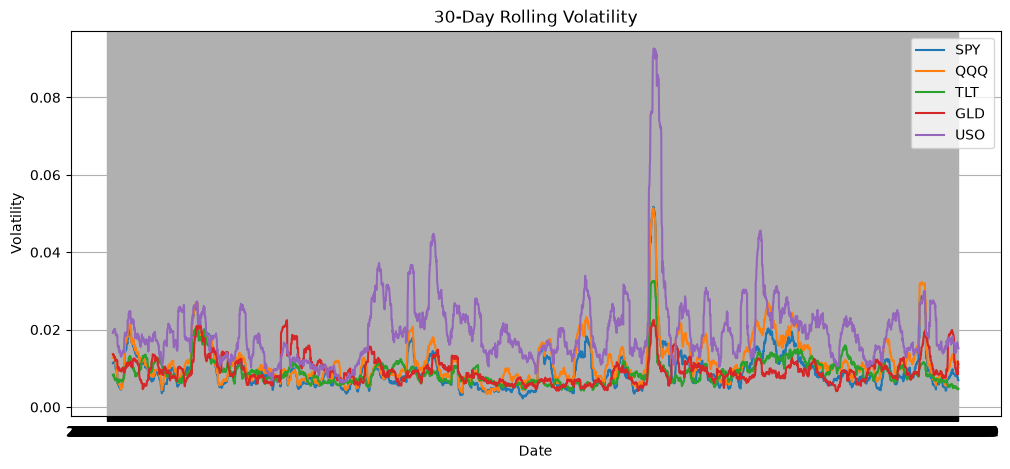

In [26]:
rolling_vol = returns.rolling(30).std()

plt.figure(figsize=(12, 5))

for ticker in ["SPY", "QQQ", "TLT", "GLD", "USO"]:
    plt.plot(rolling_vol.index, rolling_vol[ticker], label=ticker)

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.show()

correlation heatmap

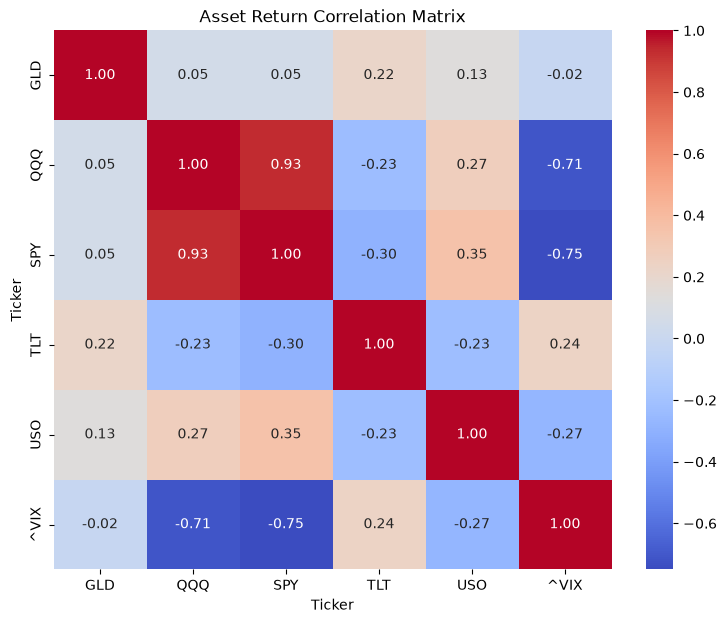

In [27]:
corr = returns.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Asset Return Correlation Matrix")
plt.show()

volatility correlation

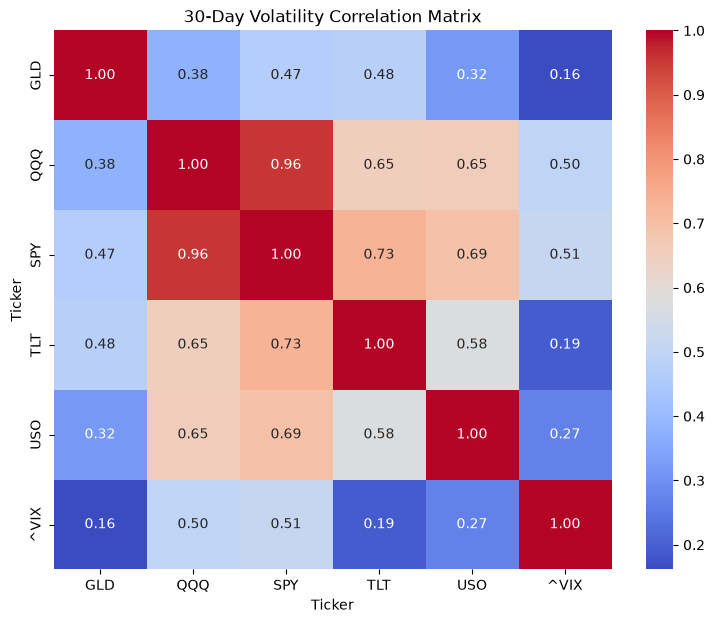

In [28]:
vol_corr = rolling_vol.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(vol_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("30-Day Volatility Correlation Matrix")
plt.show()


PCA

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize volatility features
vol_clean = rolling_vol.dropna()

scaler = StandardScaler()
vol_scaled = scaler.fit_transform(vol_clean)

# PCA
pca = PCA()
pca_features = pca.fit_transform(vol_scaled)

explained = pca.explained_variance_ratio_

print("Explained variance:")
for i, v in enumerate(explained):
    print(f"PC{i+1}: {v:.2%}")

Explained variance:
PC1: 60.73%
PC2: 15.60%
PC3: 11.68%
PC4: 6.67%
PC5: 4.78%
PC6: 0.54%


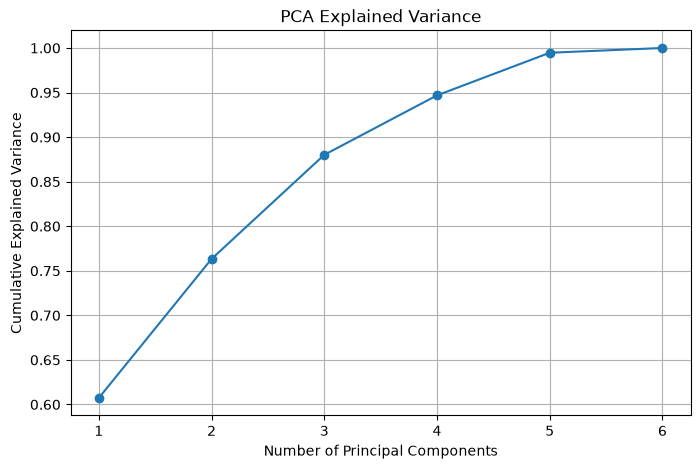

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(explained) + 1),
    np.cumsum(explained),
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

In [31]:
# SPY returns
spy_returns = returns["SPY"]

features = pd.DataFrame(index=returns.index)

# Return-based features
features["return_1d"] = spy_returns
features["return_5d"] = spy_returns.rolling(5).sum()
features["return_20d"] = spy_returns.rolling(20).sum()

# Historical volatility
features["vol_5d"] = spy_returns.rolling(5).std()
features["vol_10d"] = spy_returns.rolling(10).std()
features["vol_30d"] = spy_returns.rolling(30).std()

# VIX
features["vix"] = returns["^VIX"]

# Volume change
spy_volume = df["Volume"]["SPY"]
features["volume_change"] = spy_volume.pct_change()

# Target: NEXT 30-day volatility
features["target_vol"] = (
    spy_returns
    .rolling(30)
    .std()
    .shift(-30)
)

features = features.dropna()

print("Shape:", features.shape)
features.head()

Shape: (3964, 9)


,return_1d,return_5d,return_20d,vol_5d,vol_10d,vol_30d,vix,volume_change,target_vol
Date,,,,,,,,,
2010-02-17,0.004738,0.028149,-0.040974,0.007511,0.013232,0.011318,-0.023820,0.059803,0.005215
2010-02-18,0.005895,0.036003,-0.024910,0.006241,0.013227,0.011368,-0.050184,0.147256,0.005241
2010-02-19,0.002073,0.027610,-0.003608,0.006272,0.007054,0.011377,-0.029569,0.149587,0.005354
2010-02-22,0.000180,0.028622,0.018865,0.006027,0.007147,0.011340,-0.003996,-0.405676,0.005338
2010-02-23,-0.012145,0.000742,0.001592,0.007227,0.008122,0.011495,0.071715,0.567827,0.004838


In [32]:
pca_df = pd.DataFrame(
    pca_features[:, :4],
    index=vol_clean.index,
    columns=["PC1", "PC2", "PC3", "PC4"]
)

features = features.join(pca_df, how="inner").dropna()

print(features.shape)
features.head()

(3964, 13)


,return_1d,return_5d,return_20d,vol_5d,vol_10d,vol_30d,vix,volume_change,target_vol,PC1,PC2,PC3,PC4
Date,,,,,,,,,,,,,
2010-02-17,0.004738,0.028149,-0.040974,0.007511,0.013232,0.011318,-0.023820,0.059803,0.005215,0.537115,-0.542023,0.972065,0.310071
2010-02-18,0.005895,0.036003,-0.024910,0.006241,0.013227,0.011368,-0.050184,0.147256,0.005241,0.563303,-0.536493,0.971409,0.350407
2010-02-19,0.002073,0.027610,-0.003608,0.006272,0.007054,0.011377,-0.029569,0.149587,0.005354,0.489697,-0.448504,0.919456,0.369107
2010-02-22,0.000180,0.028622,0.018865,0.006027,0.007147,0.011340,-0.003996,-0.405676,0.005338,0.487178,-0.448216,0.912713,0.360742
2010-02-23,-0.012145,0.000742,0.001592,0.007227,0.008122,0.011495,0.071715,0.567827,0.004838,0.586356,-0.503553,0.903338,0.296750


In [33]:
X = features.drop(columns="target_vol")
y = features["target_vol"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (3964, 12)
Target: (3964,)


In [34]:
features.to_csv("../data/features.csv")